In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
data = {
    'Hours':[1,2,3,4,5,6,7,8,9,10],
    'Marks':[20,30,40,50,60,70,75,85,90,98]
}

df = pd.DataFrame(data)

df.head()

,Hours,Marks
0,1,20
1,2,30
2,3,40
3,4,50
4,5,60


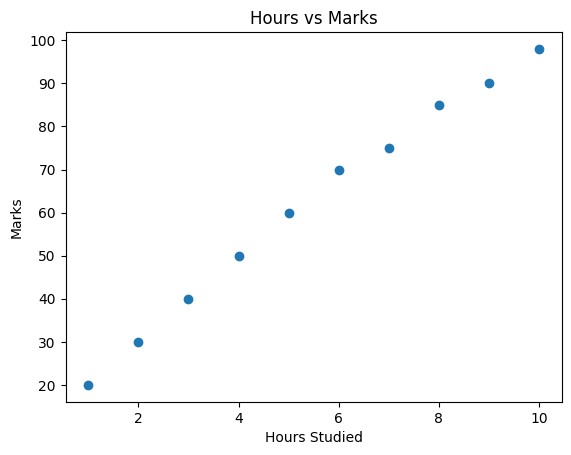

In [3]:
plt.scatter(df['Hours'], df['Marks'])
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Hours vs Marks")
plt.show()

In [4]:
X = df[['Hours']]
y = df['Marks']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [6]:
predictions = model.predict(X_test)

print("Actual Marks:")
print(y_test.values)

print("Predicted Marks:")
print(predictions)

Actual Marks:
[90 30]
Predicted Marks:
[92.78448276 31.71551724]


In [7]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 2.249999999999993
R2 Score: 0.9940575868674858


In [9]:
hours = float(input("Enter study hours: "))

prediction = model.predict([[hours]])

print(f"Predicted Marks: {prediction[0]:.2f}")

Enter study hours: 7
Predicted Marks: 75.34


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


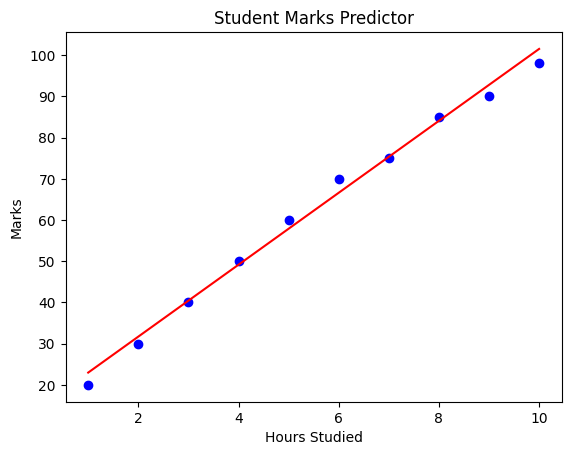

In [10]:
plt.scatter(X, y, color='blue')
plt.plot(X, model.predict(X), color='red')

plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Student Marks Predictor")

plt.show()

In [11]:
import joblib

joblib.dump(model, "student_marks_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [12]:
loaded_model = joblib.load("student_marks_model.pkl")

prediction = loaded_model.predict([[8]])
print(prediction)

[84.06034483]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [13]:
test_hours = [[2], [4], [6], [8], [10]]

predictions = model.predict(test_hours)

for hour, mark in zip(test_hours, predictions):
    print(f"{hour[0]} hours -> {mark:.2f} marks")

2 hours -> 31.72 marks
4 hours -> 49.16 marks
6 hours -> 66.61 marks
8 hours -> 84.06 marks
10 hours -> 101.51 marks


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [15]:
test_predictions = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": test_predictions
})

comparison

,Actual,Predicted
0,90,92.784483
1,30,31.715517


In [16]:
while True:
    hours = input("Enter study hours (or 'q' to quit): ")

    if hours.lower() == 'q':
        break

    hours = float(hours)

    marks = model.predict([[hours]])

    print(f"Predicted Marks: {marks[0]:.2f}\n")

Enter study hours (or 'q' to quit): 10


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Predicted Marks: 101.51

Enter study hours (or 'q' to quit): q
